In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

from sympy.abc import x

In [16]:
def sinu_curve(x:float, s=1.0, k=1.0, flip=False):
    if 0 <= x <= 1:
        if not flip:
            return np.sin(np.pi * x**s) ** k
        else:
            return np.sin(np.pi * (1 - x)**s) ** k
    else:
        return 0

def curve_inner(x:float, s=1.0, k=1.0, flip=False):
    return sinu_curve(x, s, k, flip)

In [17]:
def pdf(x:float, alpha=0.0, delta=1.0, s=1.0, k=1.0, flip=False):
    area, _ = integrate.quad(lambda z: sinu_curve(z, s, k, flip), 0, 1)
    if area == 0:
        raise ValueError("The area under the curve is zero, cannot normalize the PDF.")

    if alpha <= x <= alpha + delta:
        z = (x - alpha) / delta
        return 1 / (area * delta) * curve_inner(z, s, k, flip)
    else:
        return 0

def cdf(x:float, alpha=0.0, delta=1.0, s=1.0, k=1.0, flip=False):
    if x < alpha:
        return 0
    elif x > alpha + delta:
        return 1
    else:
        result, _ = integrate.quad(lambda t: pdf(t, alpha, delta, s, k, flip), alpha, x)
        return result

In [25]:
def string_to_function(expression):
    def function(x):
        return eval(expression)
    return function

def curve(f:str, x_min=0, x_max=1, num_points=100, **kwargs):
    x_vals = np.linspace(x_min, x_max, num_points)
    y = string_to_function(f)
    y_vals = [y(x) for x in x_vals]
    
    plt.plot(x_vals, y_vals, **kwargs)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Plot of the function f(x)')
    plt.grid(True)
    plt.show()

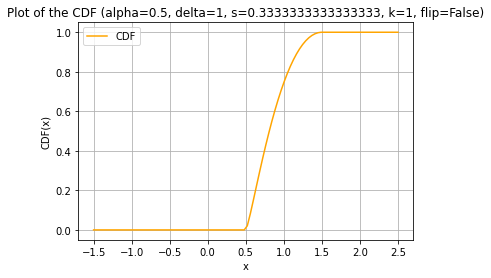

In [7]:
def plot_cdf(alpha=0, delta=1, s=1, k=1, flip=False):
    """
    Plots the CDF over a specified range of x values.
    Parameters:
        alpha (float): The location parameter.
        delta (float): The scale parameter.
        s (float): Shape parameter for sinu_curve.
        k (float): Exponent parameter for sinu_curve.
        flip (bool): Whether to flip the sinusoidal curve.
    """
    # Define the range of x values for plotting
    x_values = np.linspace(alpha - 2 * delta, alpha + 2 * delta, 100)
    y_values = [cdf(x, alpha, delta, s, k, flip) for x in x_values]

    # Plot the result
    plt.plot(x_values, y_values, label='CDF', color='orange')
    plt.xlabel('x')
    plt.ylabel('CDF(x)')
    plt.title(f'Plot of the CDF (alpha={alpha}, delta={delta}, s={s}, k={k}, flip={flip})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
plot_cdf(0.5, 1, s=1/3, k=1, flip=False)

In [ ]:
def rmom(r=1, alpha=0, delta=1, s=1, k=1, flip=False):
    integrand = lambda x: x**r * pdf(x, alpha, delta, s, k, flip)
    moment, _ = integrate.quad(integrand, alpha, alpha + delta)
    return moment

def cmom(r=1, alpha=0, delta=1, s=1, k=1, flip=False):
    mu = rmom(1, alpha, delta, s, k, flip)
    integrand = lambda x: (x-mu)**r * pdf(x, alpha, delta, s, k, flip)
    moment, _ = integrate.quad(integrand, alpha, alpha + delta)
    return moment

In [ ]:
def mean(alpha=0, delta=1, s=1, k=1, flip=False):
    return rmom(1, alpha, delta, s, k, flip)

def var(alpha=0, delta=1, s=1, k=1, flip=False):
    return cmom(2, alpha, delta, s, k, flip)

def skew(alpha=0, delta=1, s=1, k=1, flip=False):
    mu2 = cmom(2, alpha, delta, s, k, flip)
    mu3 = cmom(3, alpha, delta, s, k, flip)
    return mu3/mu2 **1.5

def kurt(alpha=0, delta=1, s=1, k=1, flip=False):
    mu2 = cmom(2, alpha, delta, s, k, flip)
    mu4 = cmom(4, alpha, delta, s, k, flip)
    
    return mu4/mu2**2 - 3